<a href="https://colab.research.google.com/github/Albertoromero-01/Inteligencia_Artificial/blob/main/Actividades/PIA_IAyRN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Producto Integrado de Aprendizaje PIA

## Redes Neuronales Artificiales

####Equipo:

N5 José Alberto Romero Francisco 2000506

N5 Daniel Alessandro Campa Torres 2095970

V6 Jaidy Rubi Gil Briones 2099573

V6 David Alvarado Cantú 2094638

V6 Azael Francisco Manuel 2101550

### Carga y Exploración Inicial de Datos

In [ ]:
import pandas as pd

# Cargar el archivo CSV desde Google Drive
data = pd.read_csv("/content/drive/MyDrive/colores.csv")

# Mostrar las primeras filas
print(data.head())

     R    G   B  Color
0  120   30  25   Rojo
1  130   28  20   Rojo
2  115   35  30   Rojo
3   20  100  40  Verde
4   25  110  35  Verde


### Definición y Entrenamiento de la Red Neuronal para Clasificación de Colores

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# 1. Cargar dataset
data = pd.read_csv("/content/drive/MyDrive/colores.csv")
X = data[["R","G","B"]].values
y = data["Color"].astype("category").cat.codes

# 2. One-hot encoding
y_cat = to_categorical(y);

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2)

# 4. Definir red neuronal con Dropout usando Input layer
model = Sequential([
    tf.keras.Input(shape=(3,)), # Usamos Input(shape=...) para definir la forma de entrada
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(12, activation='relu'),
    Dropout(0.2),
    Dense(y_cat.shape[1], activation='softmax')
])

# 5. Compilar y entrenar
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_nn = model.fit(X_train, y_train, epochs=50, batch_size=4, validation_data=(X_test, y_test))

# 6. Guardar modelo en formato TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("modelo_colores.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Modelo entrenado y exportado como modelo_colores.tflite")

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.2857 - loss: 18.7293 - val_accuracy: 0.5000 - val_loss: 46.5772
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4286 - loss: 41.7602 - val_accuracy: 0.5000 - val_loss: 45.0502
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5714 - loss: 18.2216 - val_accuracy: 0.5000 - val_loss: 43.4676
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5714 - loss: 28.5318 - val_accuracy: 0.5000 - val_loss: 41.8642
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2857 - loss: 17.8739 - val_accuracy: 0.5000 - val_loss: 40.3049
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7143 - loss: 23.9247 - val_accuracy: 0.5000 - val_loss: 38.7782
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7143 - loss: 21.7917 - val_accuracy: 0.5000 - val_loss: 37.2558
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2857 - loss: 34.8411 - val_accuracy: 0.5000 - v

### Visualización del Historial de Entrenamiento de la Red Neuronal

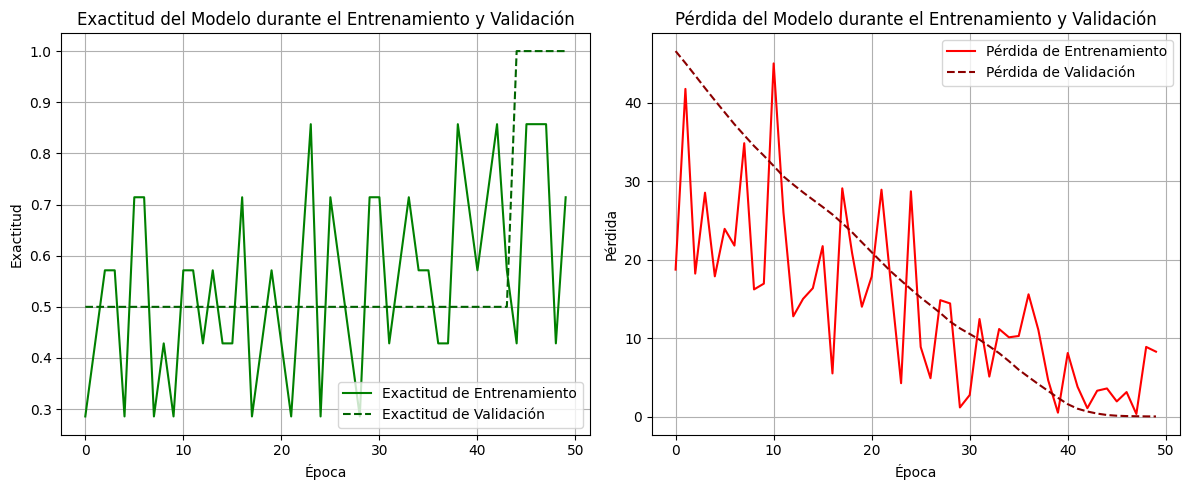

In [32]:
import matplotlib.pyplot as plt

# Graficar la exactitud (accuracy)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Un gráfico para la exactitud
plt.plot(history_nn.history['accuracy'], label='Exactitud de Entrenamiento', color='green')
plt.plot(history_nn.history['val_accuracy'], label='Exactitud de Validación', color='darkgreen', linestyle='--')
plt.title('Exactitud del Modelo durante el Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.grid(True)

# Graficar la pérdida (loss)
plt.subplot(1, 2, 2) # Otro gráfico para la pérdida
plt.plot(history_nn.history['loss'], label='Pérdida de Entrenamiento', color='red')
plt.plot(history_nn.history['val_loss'], label='Pérdida de Validación', color='darkred', linestyle='--')
plt.title('Pérdida del Modelo durante el Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout() # Ajusta el diseño para evitar superposiciones
plt.show()

### Clasificador de Árbol de Decisiones

Un **Árbol de Decisiones** es un algoritmo de aprendizaje supervisado no paramétrico que se utiliza para tareas de clasificación y regresión. Funciona creando una serie de decisiones (nodos) basadas en las características de entrada para llegar a una conclusión (hoja o predicción).

**Ventajas:**
*   Fácil de entender e interpretar (visualizable).
*   Requiere poca preparación de datos.
*   Puede manejar tanto datos numéricos como categóricos.

**Desventajas:**
*   Pueden ser propensos a sobreajuste.
*   Pueden ser inestables a pequeños cambios en los datos.

Aquí implementaremos un árbol de decisiones para clasificar los colores y compararemos su precisión con el modelo de red neuronal.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np # Importar numpy

# Dividir los datos nuevamente para el árbol de decisiones, usando 'y' (etiquetas numéricas) directamente
# en lugar de y_cat (one-hot encoded), ya que los árboles de decisión no requieren one-hot encoding.
# Aseguramos que 'data' esté cargado.
if 'data' not in locals():
    data = pd.read_csv("/content/drive/MyDrive/colores.csv")
y_dt = data["Color"].astype("category").cat.codes # Usamos las etiquetas numéricas originales

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y_dt, test_size=0.2, random_state=42)

# 1. Crear el clasificador de árbol de decisiones
dt_classifier = DecisionTreeClassifier(random_state=42)

# 2. Entrenar el modelo
dt_classifier.fit(X_train_dt, y_train_dt)

# 3. Hacer predicciones en el conjunto de prueba
y_pred_dt = dt_classifier.predict(X_test_dt)

# 4. Calcular la precisión
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)

print(f"Precisión del Árbol de Decisiones: {accuracy_dt:.4f}")

# Opcional: Predicción para los mismos valores RGB de ejemplo
# (Necesitamos asegurarnos de que el formato de entrada sea el mismo que el usado para entrenar)
new_rgb_values = np.array([[125, 32, 28]], dtype=np.float32)
predicted_class_index_dt = dt_classifier.predict(new_rgb_values)

# Asegurarse de que `category_map` esté disponible para la predicción
if 'category_map' not in locals():
    color_categories = data["Color"].astype("category")
    category_map = dict(enumerate(color_categories.cat.categories))

predicted_color_dt = category_map[predicted_class_index_dt[0]]
print(f"El color predicho por el Árbol de Decisiones para {new_rgb_values[0]} es: {predicted_color_dt}")

Precisión del Árbol de Decisiones: 1.0000
El color predicho por el Árbol de Decisiones para [125.  32.  28.] es: Rojo


### Visualización del Árbol de Decisiones con `plot_tree`

Esta visualización utiliza `matplotlib` y es otra forma de inspeccionar la estructura del árbol de decisiones.

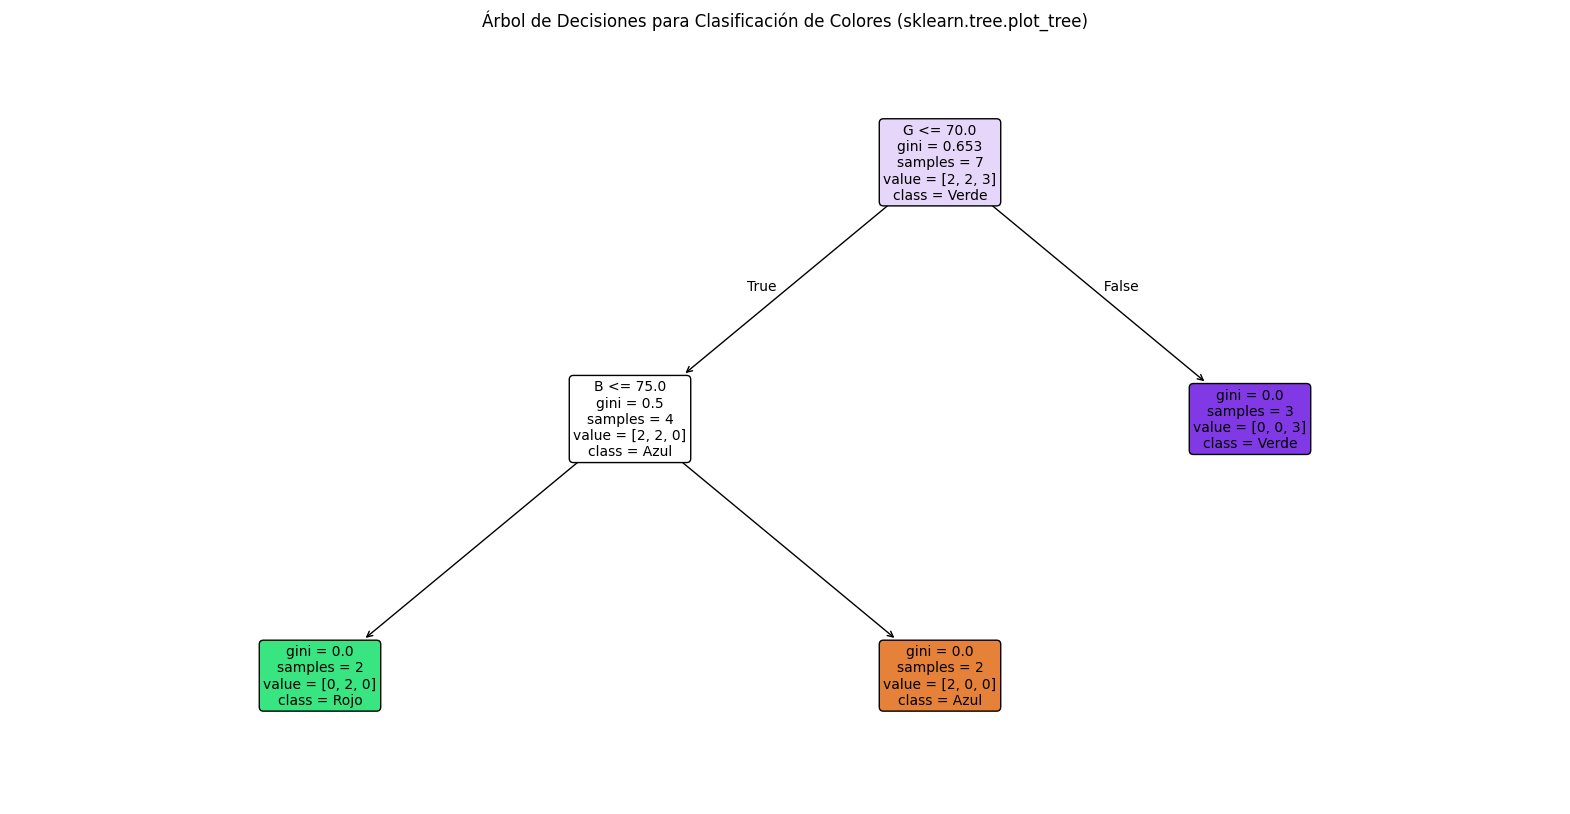

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Asegurarnos de que el clasificador de árbol de decisiones esté definido
if 'dt_classifier' not in locals():
    print("El clasificador de árbol de decisiones no está definido. Por favor, ejecuta la celda anterior.")
else:
    # Asegurarse de que `feature_names` y `class_names` estén disponibles
    if 'feature_names' not in locals():
        feature_names = ['R', 'G', 'B']
    if 'class_names' not in locals():
        if 'data' not in locals():
            data = pd.read_csv("/content/drive/MyDrive/colores.csv")
        color_categories = data["Color"].astype("category")
        category_map = dict(enumerate(color_categories.cat.categories))
        class_names = [category_map[i] for i in sorted(category_map.keys())]

    plt.figure(figsize=(20, 10)) # Ajustar el tamaño para mejor visualización
    plot_tree(dt_classifier,
              feature_names=feature_names,
              class_names=class_names,
              filled=True, rounded=True,
              fontsize=10)
    plt.title('Árbol de Decisiones para Clasificación de Colores (sklearn.tree.plot_tree)')
    plt.show()

### Visualización 3D de la Distribución de Colores RGB

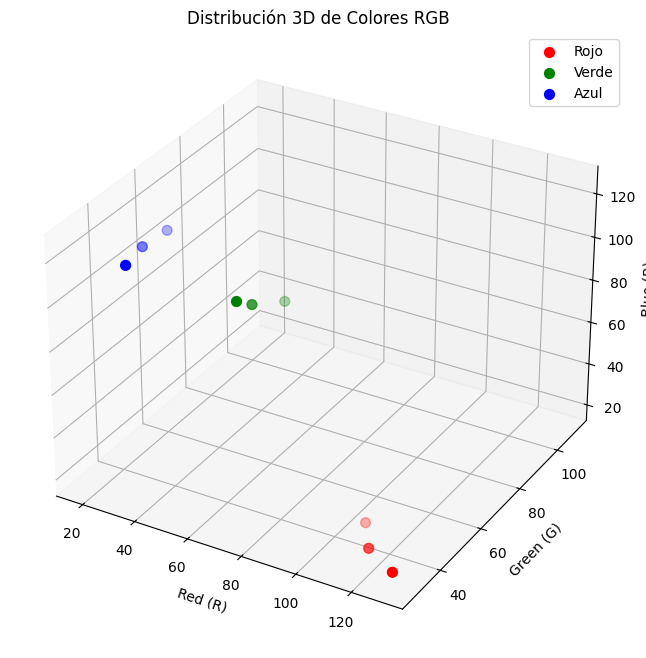

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Ensure the data is loaded (if not already in the current session)
if 'data' not in locals():
    data = pd.read_csv("/content/drive/MyDrive/colores.csv")

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Get unique colors
unique_colors = data['Color'].unique()

# Define a mapping from Spanish color names to English matplotlib colors
color_plot_map = {
    'Rojo': 'red',
    'Verde': 'green',
    'Azul': 'blue'
}

# Plot each color category
for color_name in unique_colors:
    subset = data[data['Color'] == color_name]
    # Use the defined color_plot_map, default to 'gray' if color_name not found
    plot_color = color_plot_map.get(color_name, 'gray')
    ax.scatter(subset['R'], subset['G'], subset['B'],
               color=plot_color, label=color_name, s=50)

# Set labels and title
ax.set_xlabel('Red (R)')
ax.set_ylabel('Green (G)')
ax.set_zlabel('Blue (B)')
ax.set_title('Distribución 3D de Colores RGB')
ax.legend()
ax.grid(True)
plt.show()

### Predicción con el modelo TFLite

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

# 1. Cargar el modelo TFLite
interpreter = tf.lite.Interpreter(model_path="modelo_colores.tflite")
interpreter.allocate_tensors()

# Obtener detalles de entrada y salida
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. Preparar datos de entrada para una nueva predicción
# Por ejemplo, intentemos predecir el color de un nuevo conjunto de valores RGB (similar al rojo)
new_rgb_values = np.array([[125, 32, 28]], dtype=np.float32)

# Asegurarse de que el tipo de datos de entrada coincide con lo esperado por el modelo
interpreter.set_tensor(input_details[0]['index'], new_rgb_values)

# 3. Ejecutar la inferencia
interpreter.invoke()

# 4. Obtener el resultado de la predicción
predictions = interpreter.get_tensor(output_details[0]['index'])

# Las predicciones son probabilidades para cada clase. Necesitamos la clase con mayor probabilidad.
predicted_class_index = np.argmax(predictions)

# Para mapear el índice predicho de vuelta al nombre del color, necesitamos el mapeo original.
# Recargamos los datos para obtener el mapeo de categorías si 'data' no está en el scope
if 'data' not in locals():
    data = pd.read_csv("/content/drive/MyDrive/colores.csv")

# Recrear el mapeo de categorías a códigos numéricos
color_categories = data["Color"].astype("category")
category_map = dict(enumerate(color_categories.cat.categories))

predicted_color = category_map[predicted_class_index]

print(f"Valores RGB de entrada: {new_rgb_values[0]}")
print(f"Predicción de probabilidades: {predictions[0]}")
print(f"El color predicho es: {predicted_color}")

Valores RGB de entrada: [125.  32.  28.]
Predicción de probabilidades: [6.5735287e-07 1.5416049e-03 9.9845767e-01]
El color predicho es: Verde


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
import os

# This command converts the .tflite model to a C header file
# We already did this when creating the initial model, but demonstrating here for clarity.
# The file 'modelo_colores.h' should already exist in the Colab environment.
!xxd -i modelo_colores.tflite > modelo_colores.h

# You can view the contents of the generated header file (optional)
# with open('modelo_colores.h', 'r') as f:
#     print(f.read())

print("Generated modelo_colores.h file. You can now download it and include it in your Arduino project.")


Generated modelo_colores.h file. You can now download it and include it in your Arduino project.


```cpp
#include <TensorFlowLite.h>
#include <tensorflow/lite/micro/all_ops_resolver.h>
#include <tensorflow/lite/micro/micro_error_reporter.h>
#include <tensorflow/lite/micro/micro_interpreter.h>
#include <tensorflow/lite/schema/schema_generated.h>

// Incluye el archivo de cabecera generado con el modelo TFLite
// Asegúrate de que este archivo 'modelo_colores.h' esté en la misma carpeta que tu .ino
#include "modelo_colores.h"

// Variables globales para el modelo
const tflite::Model* model = nullptr;
tflite::MicroInterpreter* interpreter = nullptr;
tflite::MicroErrorReporter tflErrorReporter;
tflite::AllOpsResolver tflOpsResolver;

// Una arena de memoria para los tensores de entrada, salida y intermedios.
// El tamaño exacto dependerá de tu modelo.
constexpr int kTensorArenaSize = 2 * 1024; // Ajusta este valor según sea necesario
uint8_t tensor_arena[kTensorArenaSize];

// Punteros a los tensores de entrada y salida del modelo
TfLiteTensor* input = nullptr;
TfLiteTensor* output = nullptr;

// Función para mapear el índice de la clase a un nombre de color
// Deberás obtener este mapeo de cómo entrenaste tu modelo.
const char* get_color_name(int class_index) {
  switch (class_index) {
    case 0: return "Azul";
    case 1: return "Rojo";
    case 2: return "Verde";
    default: return "Desconocido";
  }
}

void setup_model() {
  // Mapea el modelo al espacio de memoria Flash
  model = tflite::GetModel(modelo_colores_tflite);
  if (model->version() != TFLITE_SCHEMA_VERSION) {
    TF_LITE_REPORT_ERROR(&tflErrorReporter, "La versión del modelo no coincide con la versión de la librería: esperado %d, got %d",
                         TFLITE_SCHEMA_VERSION, model->version());
    return;
  }

  // Construye un intérprete para ejecutar el modelo
  interpreter = new tflite::MicroInterpreter(
      model, tflOpsResolver, tensor_arena, kTensorArenaSize, &tflErrorReporter);

  // Asigna los tensores. Esto debe hacerse una vez al inicio.
  TfLiteStatus allocate_status = interpreter->AllocateTensors();
  if (allocate_status != kTfLiteOk) {
    TF_LITE_REPORT_ERROR(&tflErrorReporter, "Fallo en la asignación de tensores");
    return;
  }

  // Obtener punteros a los tensores de entrada y salida
  input = interpreter->input(0);
  output = interpreter->output(0);
}

void loop_prediction(int red_val, int green_val, int blue_val) {
  // Asegúrate de que el modelo esté inicializado
  if (input == nullptr) {
    setup_model();
  }
  
  // Copia los valores del sensor RGB al tensor de entrada del modelo
  // Asegúrate de que los tipos de datos coincidan (float32 en este caso)
  input->data.f[0] = static_cast<float>(red_val);
  input->data.f[1] = static_cast<float>(green_val);
  input->data.f[2] = static_cast<float>(blue_val);

  // Ejecuta la inferencia
  TfLiteStatus invoke_status = interpreter->Invoke();
  if (invoke_status != kTfLiteOk) {
    TF_LITE_REPORT_ERROR(&tflErrorReporter, "Fallo al invocar la inferencia");
    return;
  }

  // Obtener las probabilidades de salida y determinar la clase predicha
  float max_prob = 0.0f;
  int predicted_class_index = -1;
  for (int i = 0; i < output->dims->data[1]; ++i) {
    if (output->data.f[i] > max_prob) {
      max_prob = output->data.f[i];
      predicted_class_index = i;
    }
  }

  // Imprime el color predicho
  Serial.print("Color predicho por TFLite: ");
  Serial.println(get_color_name(predicted_class_index));
}

// Modifica tu setup() de Arduino para incluir la inicialización del modelo
void setup() {
  // ... tu código setup existente ...
  Serial.begin(9600);
  setup_model(); // Inicializa el modelo TFLite
}

// Modifica tu loop() de Arduino para incluir la predicción
void loop() {
  // ... tu código de lectura de sensor RGB existente ...
  int rojo = pulseIn(salidaTCS, LOW);
  int verde = pulseIn(salidaTCS, LOW);  
  int azul = pulseIn(salidaTCS, LOW);
  
  // Llama a la función de predicción con los valores del sensor
  loop_prediction(rojo, verde, azul);

  // ... el resto de tu código loop existente ...
}
```

#### Explicación Adicional:

1.  **`#include

### Descarga del Modelo TFLite

In [ ]:
from google.colab import files

files.download('modelo_colores.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>